In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# Cargar datos
df = pd.read_csv('equipos_kpi_30dias.csv')
df['fecha'] = pd.to_datetime(df['fecha'])

print("=== EXPLORACIÓN DEL DATASET ===")
print(f"Filas x Columnas : {df.shape[0]} x {df.shape[1]}")
print(f"Equipos          : {df['equipo_id'].unique().tolist()}")
print()
print("Tipos de datos:")
print(df.dtypes)
print()
print("Primeras filas:")
df.head()

=== EXPLORACIÓN DEL DATASET ===
Filas x Columnas : 90 x 9
Equipos          : ['COMPRESOR-A1', 'BOMBA-B2', 'MOTOR-C3']

Tipos de datos:
fecha            datetime64[ns]
equipo_id                object
t_planificado             int64
t_operativo             float64
t_reparacion            float64
n_fallas                  int64
prod_teorica              int64
prod_real                 int64
piezas_ok                 int64
dtype: object

Primeras filas:


,fecha,equipo_id,t_planificado,t_operativo,t_reparacion,n_fallas,prod_teorica,prod_real,piezas_ok
0,2026-04-01,COMPRESOR-A1,24,21.2,0.0,0,500,419,415
1,2026-04-02,COMPRESOR-A1,24,21.5,0.0,0,500,402,395
2,2026-04-03,COMPRESOR-A1,24,22.1,0.0,0,500,432,426
3,2026-04-04,COMPRESOR-A1,24,20.5,0.0,0,500,390,383
4,2026-04-05,COMPRESOR-A1,24,19.2,1.3,1,500,357,354


##  Cálculo de KPIs por Equipo
- **Disponibilidad** = t_operativo / t_planificado  
- **Rendimiento** = prod_real / prod_teorica  
- **Calidad** = piezas_ok / prod_real  
- **OEE** = Disponibilidad × Rendimiento × Calidad  
- **MTBF** = (t_total − t_reparacion) / n_fallas  
- **MTTR** = t_reparacion / n_fallas

In [3]:
def calcular_kpis(g):
    disp  = g['t_operativo'].sum() / g['t_planificado'].sum()
    rend  = g['prod_real'].sum()   / g['prod_teorica'].sum()
    cal   = g['piezas_ok'].sum()   / g['prod_real'].sum()
    oee   = disp * rend * cal
    nf    = g['n_fallas'].sum()
    trep  = g['t_reparacion'].sum()
    tplan = g['t_planificado'].sum()
    mtbf  = (tplan - trep) / nf if nf > 0 else np.nan
    mttr  = trep / nf            if nf > 0 else 0
    return pd.Series({
        'Disponibilidad (%)': round(disp * 100, 2),
        'Rendimiento (%)':    round(rend * 100, 2),
        'Calidad (%)':        round(cal  * 100, 2),
        'OEE (%)':            round(oee  * 100, 2),
        'MTBF (h)':           round(mtbf, 2),
        'MTTR (h)':           round(mttr, 2),
    })

kpis = df.groupby('equipo_id').apply(calcular_kpis).reset_index()
kpis

/tmp/ipykernel_9035/520699597.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  kpis = df.groupby('equipo_id').apply(calcular_kpis).reset_index()


,equipo_id,Disponibilidad (%),Rendimiento (%),Calidad (%),OEE (%),MTBF (h),MTTR (h)
0,BOMBA-B2,75.90,67.92,96.39,49.69,43.36,1.64
1,COMPRESOR-A1,85.51,79.27,98.25,66.60,88.38,1.63
2,MOTOR-C3,89.64,84.26,98.61,74.48,717.40,2.60


##  Gráfico Comparativo de OEE

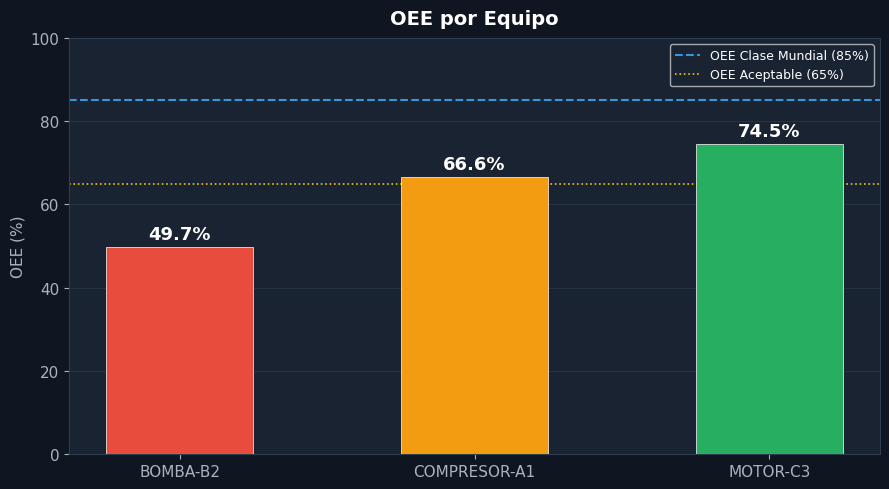

In [4]:
colors  = {'BOMBA-B2':'#E74C3C', 'COMPRESOR-A1':'#F39C12', 'MOTOR-C3':'#27AE60'}
equipos = kpis['equipo_id'].tolist()

fig, ax = plt.subplots(figsize=(9, 5), facecolor='#0F1621')
ax.set_facecolor('#1A2332')
bars = ax.bar(kpis['equipo_id'], kpis['OEE (%)'],
              color=[colors[e] for e in equipos],
              width=0.5, edgecolor='white', linewidth=0.5, zorder=3)
ax.axhline(85, color='#3498DB', linestyle='--', linewidth=1.5, label='OEE Clase Mundial (85%)')
ax.axhline(65, color='#F1C40F', linestyle=':',  linewidth=1.2, label='OEE Aceptable (65%)')
for bar, val in zip(bars, kpis['OEE (%)']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=13,
            fontweight='bold', color='white')
ax.set_ylim(0, 100)
ax.set_title('OEE por Equipo', color='white', fontsize=14, fontweight='bold', pad=10)
ax.set_ylabel('OEE (%)', color='#AAB4BE', fontsize=11)
ax.tick_params(colors='#AAB4BE', labelsize=11)
ax.spines[:].set_color('#2C3E50')
ax.yaxis.grid(True, color='#2C3E50', alpha=0.6, zorder=0)
ax.legend(fontsize=9, facecolor='#1A2332', labelcolor='white')
plt.tight_layout()
plt.savefig('oee_comparativo.png', dpi=150, facecolor='#0F1621')
plt.show()

##  Tendencia Semanal de Disponibilidad

/tmp/ipykernel_9035/2923719206.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  disp_sem = df.groupby(['equipo_id','semana']).apply(


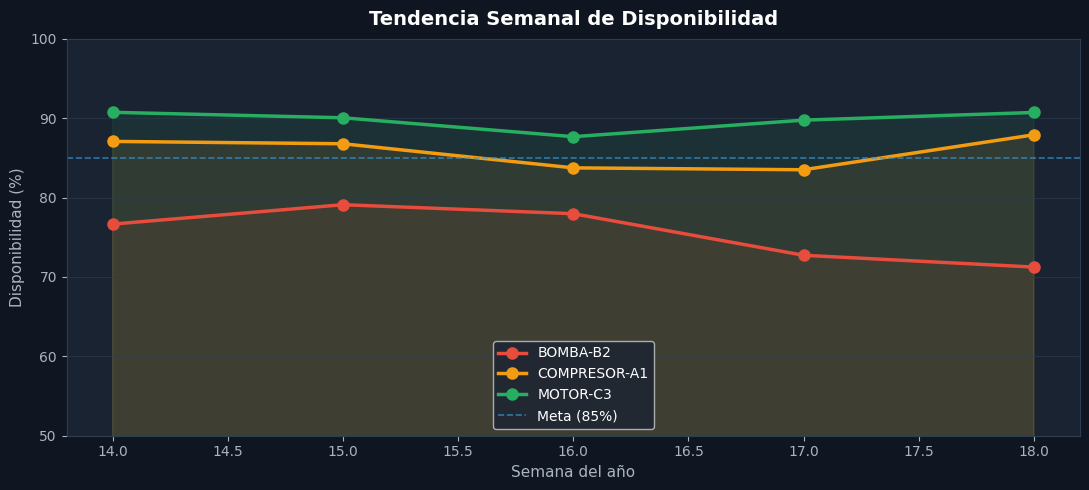

In [5]:
df['semana'] = df['fecha'].dt.isocalendar().week
disp_sem = df.groupby(['equipo_id','semana']).apply(
    lambda g: g['t_operativo'].sum() / g['t_planificado'].sum() * 100
).reset_index(name='Disponibilidad')

fig, ax = plt.subplots(figsize=(11, 5), facecolor='#0F1621')
ax.set_facecolor('#1A2332')
for equipo in equipos:
    sub = disp_sem[disp_sem['equipo_id']==equipo].sort_values('semana')
    ax.plot(sub['semana'], sub['Disponibilidad'], marker='o',
            color=colors[equipo], linewidth=2.5, markersize=8, label=equipo)
    ax.fill_between(sub['semana'], sub['Disponibilidad'], alpha=0.10, color=colors[equipo])
ax.axhline(85, color='#3498DB', linestyle='--', linewidth=1.2, alpha=0.7, label='Meta (85%)')
ax.set_ylim(50, 100)
ax.set_title('Tendencia Semanal de Disponibilidad', color='white', fontsize=14, fontweight='bold', pad=10)
ax.set_xlabel('Semana del año', color='#AAB4BE', fontsize=11)
ax.set_ylabel('Disponibilidad (%)', color='#AAB4BE', fontsize=11)
ax.tick_params(colors='#AAB4BE', labelsize=10)
ax.spines[:].set_color('#2C3E50')
ax.yaxis.grid(True, color='#2C3E50', alpha=0.6)
ax.legend(fontsize=10, facecolor='#1A2332', labelcolor='white')
plt.tight_layout()
plt.savefig('disponibilidad_semanal.png', dpi=150, facecolor='#0F1621')
plt.show()

## Identificación del Equipo con Peor Rendimiento

In [6]:
peor = kpis.sort_values('OEE (%)').iloc[0]
print(f"Equipo con PEOR OEE : {peor['equipo_id']} — {peor['OEE (%)']:.1f}%")
print()
print("Componentes del OEE:")
print(f"  Disponibilidad : {peor['Disponibilidad (%)']:.1f}%  ← PROBLEMA PRINCIPAL (meta: >85%)")
print(f"  Rendimiento    : {peor['Rendimiento (%)']:.1f}%   ← PROBLEMA SECUNDARIO  (meta: >95%)")
print(f"  Calidad        : {peor['Calidad (%)']:.1f}%  (dentro de rango aceptable)")
print()
print(f"MTBF : {peor['MTBF (h)']:.1f} h  → Falla cada ~43 h de operacion (muy frecuente)")
print(f"MTTR : {peor['MTTR (h)']:.1f} h  → Tiempo de reparacion promedio")
print()
print("Conclusion: El problema principal de BOMBA-B2 reside en DISPONIBILIDAD y RENDIMIENTO.")
print("La calidad se mantiene alta (96.4%), lo que descarta problemas de proceso o materia prima.")

Equipo con PEOR OEE : BOMBA-B2 — 49.7%

Componentes del OEE:
  Disponibilidad : 75.9%  ← PROBLEMA PRINCIPAL (meta: >85%)
  Rendimiento    : 67.9%   ← PROBLEMA SECUNDARIO  (meta: >95%)
  Calidad        : 96.4%  (dentro de rango aceptable)

MTBF : 43.4 h  → Falla cada ~43 h de operacion (muy frecuente)
MTTR : 1.6 h  → Tiempo de reparacion promedio

Conclusion: El problema principal de BOMBA-B2 reside en DISPONIBILIDAD y RENDIMIENTO.
La calidad se mantiene alta (96.4%), lo que descarta problemas de proceso o materia prima.


##  Recomendaciones al Gerente de Planta

---

### INFORME EJECUTIVO — Priorización de Mantenimiento

**Equipo a priorizar: BOMBA-B2**

Luego del análisis de los indicadores industriales correspondientes a los últimos 30 días de operación, se concluye que el equipo **BOMBA-B2** presenta el rendimiento global más crítico de los tres equipos evaluados, con un **OEE de apenas 49,7%**, muy por debajo del umbral de clase mundial del 85% e incluso por debajo del mínimo aceptable del 65%.

El desglose de los componentes del OEE revela que los dos factores más comprometidos son la **Disponibilidad (75,9%)** y el **Rendimiento (67,9%)**. La baja disponibilidad indica que la bomba pasa una proporción significativa del tiempo planificado fuera de servicio, ya sea en reparaciones correctivas o en paradas no programadas. El bajo rendimiento señala que incluso cuando el equipo está en funcionamiento, no logra alcanzar los ritmos de producción teóricos establecidos, lo que puede deberse a desgaste mecánico, pérdidas de presión, cavitación, o fugas en sellos y válvulas.

El **MTBF de 43,4 horas** confirma la alta frecuencia de fallas: la bomba falla en promedio cada 43 horas de operación, alarmante en comparación con el MOTOR-C3, que presenta un MTBF de 717 horas. Este indicador revela que la BOMBA-B2 se encuentra en un estado de mantenimiento reactivo puro, lo cual incrementa los costos, interrumpe la cadena de producción y pone en riesgo la integridad del equipo a largo plazo.

**Acciones técnicas recomendadas:**

1. **Inspección completa e inmediata** del sistema de rodamientos, sellos mecánicos y cuerpo de bomba para detectar fugas, desgaste y desalineación.
2. **Implementar un plan de mantenimiento preventivo** con intervalos no mayores a 30 horas de operación, basado en los datos históricos de fallas.
3. **Monitoreo de vibraciones y temperatura** en tiempo real mediante sensores IoT para anticipar fallas (mantenimiento predictivo).
4. **Revisión del sistema hidráulico** asociado: verificar presiones de suministro, obstrucciones en tuberías y estado de válvulas de control.
5. **Análisis de lubricantes** para detectar contaminación o degradación prematura que contribuya al desgaste acelerado.

En conclusión, la BOMBA-B2 debe ser la prioridad número uno del área de mantenimiento. Una mejora del OEE de tan solo 15 puntos porcentuales en este equipo tendría un impacto directo en la productividad global de la planta, superior al que se lograría optimizando cualquiera de los otros dos equipos.
